In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

In [2]:
original_df=pd.read_csv("with_login.csv")

In [3]:
df=original_df.drop("jobma_catcher_id", axis=1)

In [4]:
df.shape

(4461, 15)

In [5]:
df.isna().sum()

company_size               0
is_premium                 0
subscription_status        0
jobma_catcher_status       0
sub_users                  0
wallet_amount              0
is_unlimited               0
plan_type                  0
subscription_count         0
invitations                0
pre_recorded_kit_counts    0
number_of_jobs_posted      0
pre_rec_interview_taken    0
subscription_amount_usd    0
days_since_login           0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4461 entries, 0 to 4460
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   company_size             4461 non-null   object 
 1   is_premium               4461 non-null   int64  
 2   subscription_status      4461 non-null   int64  
 3   jobma_catcher_status     4461 non-null   int64  
 4   sub_users                4461 non-null   int64  
 5   wallet_amount            4461 non-null   float64
 6   is_unlimited             4461 non-null   int64  
 7   plan_type                4461 non-null   int64  
 8   subscription_count       4461 non-null   int64  
 9   invitations              4461 non-null   int64  
 10  pre_recorded_kit_counts  4461 non-null   int64  
 11  number_of_jobs_posted    4461 non-null   int64  
 12  pre_rec_interview_taken  4461 non-null   int64  
 13  subscription_amount_usd  4461 non-null   float64
 14  days_since_login        

In [7]:
binary_columns = ['is_premium',
                  'subscription_status',
                  'jobma_catcher_status',
                  'is_unlimited',
                  'plan_type',
                 ]

categorical_columns =['company_size',
                      'days_since_login']
                   
numerical_columns= ['sub_users',
                    'wallet_amount',
                    'subscription_count',
                    'invitations',
                    'pre_recorded_kit_counts',
                    'number_of_jobs_posted',
                    'pre_rec_interview_taken',
                    'days_since_login',
                   ]

ordinal_columns =['subscription_amount_usd']

In [8]:
# Removing negatives and clamp to 0
def log_transform(X):
    X = X.copy()
    X[X <= 0] = 1e-10
    return np.log(X)

def clean_binary(X):
    return X.apply(lambda col: col.map(lambda val: 1 if pd.to_numeric(val, errors='coerce') > 0 else 0).astype(int))

def clean_categorical(X):
    return X.apply(lambda col: col.map(lambda val: str(val).strip().lower() if pd.notnull(val) else 'others'))

def clean_numerical(X):
    return X.apply(lambda col: pd.to_numeric(col, errors='coerce'))

def clean_ordinal(X):
    return X.apply(lambda col: pd.to_numeric(col, errors='coerce')).clip(lower=0)
    

In [9]:
# Binary pipeline
binary_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_binary, validate=False)),
                                  ('imputer', SimpleImputer(strategy='most_frequent')),
                                 ])

categorical_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_categorical, validate=False)),
                                       ('imputer', SimpleImputer(strategy='most_frequent')),
                                       ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
                                      ])

ordinal_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_ordinal, validate=False)),
                                   ('imputer', SimpleImputer(strategy='median')),
                                   ('log_transform', FunctionTransformer(lambda x: np.log1p(x), validate=False)),
                                  ])

numerical_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_numerical, validate=False)),
                                     ('imputer', SimpleImputer(strategy='mean')),
                                    ])

preprocessor = ColumnTransformer(transformers=[('bin', binary_pipeline, binary_columns),
                                               ('cat', categorical_pipeline, categorical_columns), 
                                               ('ord', ordinal_pipeline, ordinal_columns),
                                               ('num', numerical_pipeline, numerical_columns),
                                              ])

# Final pipeline
pipeline = Pipeline([('preprocessing', preprocessor),
                    ('scaler', StandardScaler())])

In [18]:
pipeline

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('bin',
                                                  Pipeline(steps=[('cleaner',
                                                                   FunctionTransformer(func=<function clean_binary at 0x0000027D831C3370>)),
                                                                  ('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['is_premium',
                                                   'subscription_status',
                                                   'jobma_catcher_status',
                                                   'is_unlimited',
                                                   'plan_type']),
                                                 ('cat',
                                                  Pipeline(steps=[('cleaner',
                                                                   Funct...
                                                                   FunctionTransformer(func=<function <lambda> at 0x0000027D831C3880>))]),
                                                  ['subscription_amount_usd']),
                                                 ('num',
                                                  Pipeline(steps=[('cleaner',
                                                                   FunctionTransformer(func=<function clean_numerical at 0x0000027D831C3490>)),
                                                                  ('imputer',
                                                                   SimpleImputer())]),
                                                  ['sub_users', 'wallet_amount',
                                                   'subscription_count',
                                                   'invitations',
                                                   'pre_recorded_kit_counts',
                                                   'number_of_jobs_posted',
                                                   'pre_rec_interview_taken'])])),
                ('scaler', StandardScaler())])

In [10]:
X = pipeline.fit_transform(df)
X_tensor = torch.tensor(X, dtype=torch.float32)
X_tensor.shape

torch.Size([4461, 32])

In [11]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )

        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )

    def forward(self, x):
        embeddings = self.encoder(x)
        reconstructed = self.decoder(embeddings)
        return reconstructed, embeddings

In [12]:
input_dim = X_tensor.shape[1]
model = Autoencoder(input_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 30
batch_size = 16

In [78]:
model

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=32, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=32, bias=True)
  )
)

In [13]:
loss_history = []
test_loss_history = []

for epoch in range(epochs):
    epoch_loss = 0.0
    for i in range(0, len(X_tensor), batch_size):
        x_batch = X_tensor[i:i + batch_size]

        optimizer.zero_grad()
        reconstructed, _ = model(x_batch)
        
        loss = criterion(reconstructed, x_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / (len(X_tensor) / batch_size)
    loss_history.append(avg_loss)

    if (epoch + 1) % 2 == 0:
        print(f'Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}')

Epoch 2/20, Loss: 1.1704
Epoch 4/20, Loss: 0.9319
Epoch 6/20, Loss: 0.5140
Epoch 8/20, Loss: 0.3035
Epoch 10/20, Loss: 0.1423
Epoch 12/20, Loss: 0.1054
Epoch 14/20, Loss: 0.0805
Epoch 16/20, Loss: 0.0825
Epoch 18/20, Loss: 0.0942
Epoch 20/20, Loss: 0.0657


In [14]:
#Extract embeddings and # Convert embeddings to numpy array
with torch.no_grad():
    _, embeddings = model(X_tensor)
embeddings_np = embeddings.numpy()
embeddings_np.shape

(4461, 32)

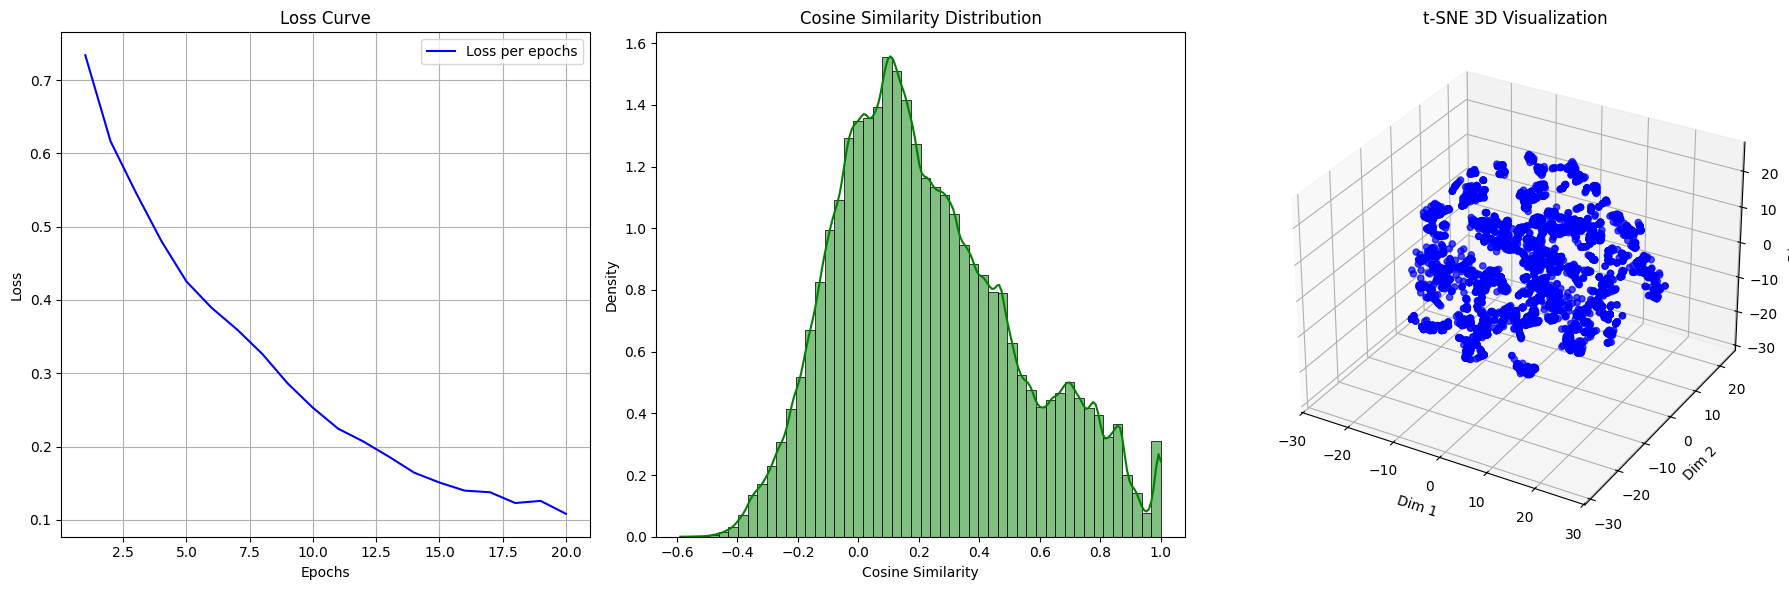

In [15]:
#Loss Curve
fig = plt.figure(figsize=(18, 6))
ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(range(1, epochs + 1), loss_history, label='Loss per epochs', color='blue')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curve')
ax1.grid(True)
ax1.legend()

#Cosine Similarity Histogram
ax2 = fig.add_subplot(1, 3, 2)
similarities = cosine_similarity(embeddings_np)
sim_scores = similarities[np.triu_indices_from(similarities, k=1)]
sns.histplot(sim_scores, bins=50, kde=True, color='green', stat='density', ax=ax2)
ax2.set_title('Cosine Similarity Distribution')
ax2.set_xlabel('Cosine Similarity')
ax2.set_ylabel('Density')

#t-SNE in 3D
ax3 = fig.add_subplot(1, 3, 3, projection='3d')
tsne = TSNE(n_components=3, random_state=42)
embeddings_3d = tsne.fit_transform(embeddings_np)
ax3.scatter(embeddings_3d[:, 0], embeddings_3d[:, 1], embeddings_3d[:, 2], c='blue', alpha=0.7)
ax3.set_title('t-SNE 3D Visualization')
ax3.set_xlabel('Dim 1')
ax3.set_ylabel('Dim 2')
ax3.set_zlabel('Dim 3')
plt.tight_layout()
plt.show()

In [16]:
def recommend_from_sample_dict(sample_dict, full_embeddings, original_df, pipeline, model, top_n=5):
    sample_df = pd.DataFrame([sample_dict])
    transformed = pipeline.transform(sample_df)
    sample_tensor = torch.tensor(transformed, dtype=torch.float32)
    
    model.eval()
    with torch.no_grad():
        _, sample_embedding = model(sample_tensor)
        
    similarities = cosine_similarity(sample_embedding, full_embeddings)[0]
    top_indices = np.argsort(similarities)[::-1][:top_n]
    result_df = original_df.iloc[top_indices].copy()
    result_df['similarity_score'] = similarities[top_indices]
    result_df.reset_index(drop=True, inplace=True)
    return result_df

In [20]:
sample_dict = { 'company_size': '101-500',
                'is_premium': 0,
                'subscription_status': 2,
                'jobma_catcher_status': 1,
                'sub_users': 0,
                'wallet_amount': 60.0,
                'is_unlimited': 0,
                'plan_type': 1,
                'subscription_count': 1,
                'invitations': 0,
                'pre_recorded_kit_counts': 0,
                'number_of_jobs_posted': 1,
                'pre_rec_interview_taken': 0,
                'subscription_amount_usd': 138.8,
                'days_since_login': '1641-5000'}

In [21]:
recommend_from_sample_dict(sample_dict, embeddings_np, original_df, pipeline, model, top_n=5)

,jobma_catcher_id,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,subscription_amount_usd,days_since_login,similarity_score
0,3307,101-500,0,2,1,0,60.0,0,1,1,0,0,0,0,13.9,1641-5000,0.857519
1,3565,101-500,0,2,1,0,60.0,0,1,1,0,0,0,0,13.9,1641-5000,0.857519
2,3575,101-500,0,2,1,0,60.0,0,1,1,0,0,0,0,13.9,1641-5000,0.857519
3,3562,101-500,0,2,1,0,60.0,0,1,1,0,0,0,0,13.9,1641-5000,0.857519
4,3549,101-500,0,2,1,0,60.0,0,1,1,0,0,0,0,12.8,1641-5000,0.857156


In [25]:
sample_dict2= { 'company_size': '26-100',
                'is_premium': 0,
                'subscription_status': 2,
                'jobma_catcher_status': 1,
                'sub_users': 0,
                'wallet_amount': 60.0,
                'is_unlimited': 0,
                'plan_type': 1,
                'subscription_count': 1,
                'invitations':15,
                'pre_recorded_kit_counts': 5,
                'number_of_jobs_posted': 25,
                'pre_rec_interview_taken': 15,
                'subscription_amount_usd': 117.8,
                'days_since_login': '1641-5000'}

In [26]:
recommend_from_sample_dict(sample_dict2, embeddings_np, original_df, pipeline, model, top_n=5)

,jobma_catcher_id,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,subscription_amount_usd,days_since_login,similarity_score
0,4065,26-100,0,2,1,1,60.0,0,1,1,1,1,1,1,1.4,1641-5000,0.911710
1,4221,26-100,0,2,1,1,60.0,0,1,1,0,0,1,0,1.4,1641-5000,0.908582
2,3394,26-100,0,2,1,1,60.0,0,1,2,53,2,2,1,16.2,1641-5000,0.908153
3,4167,26-100,0,2,1,1,60.0,0,1,2,0,0,0,0,1.5,1641-5000,0.904519
4,3478,26-100,0,2,1,1,60.0,0,1,1,0,0,0,0,0.6,1641-5000,0.902575


In [47]:
sample_dictt= { 'company_size': '26-100',
                'is_premium': 0,
                'subscription_status': 2,
                'jobma_catcher_status': 1,
                'sub_users': 11,
                'wallet_amount': 101.0,
                'is_unlimited': 0,
                'plan_type': 0,
                'subscription_count': 5,
                'invitations':15,
                'pre_recorded_kit_counts': 5,
                'number_of_jobs_posted': 15,
                'pre_rec_interview_taken': 15,
                'subscription_amount_usd': 208.8,
                'days_since_login': '1641-5000'}

In [48]:
recommend_from_sample_dict(sample_dictt, embeddings_np, original_df, pipeline, model, top_n=5)

,jobma_catcher_id,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,subscription_amount_usd,days_since_login,similarity_score
0,3131,26-100,1,2,1,7,60.0,1,0,1,0,0,0,0,0.0,1641-5000,0.891057
1,8334,500-1000,1,1,1,13,60.0,0,0,4,0,0,0,0,55.4,0-315,0.853782
2,6042,26-100,1,2,1,10,60.0,0,0,4,11,2,3,3,11.8,881-1200,0.811484
3,6977,101-500,0,2,1,11,60.0,1,0,6,0,0,0,0,595.9,0-315,0.805341
4,4088,26-100,1,2,1,5,60.0,0,0,1,0,0,0,0,5.9,1641-5000,0.802073


In [63]:
sample_dict4= { 'company_size': '1-25',
                'is_premium': 1,
                'subscription_status': 1,
                'jobma_catcher_status': 1,
                'sub_users': 5,
                'wallet_amount': 500000.0,
                'is_unlimited': 0,
                'plan_type': 0,
                'subscription_count': 5,
                'invitations':15,
                'pre_recorded_kit_counts': 5,
                'number_of_jobs_posted': 4,
                'pre_rec_interview_taken': 25,
                'subscription_amount_usd': 347.1,
                'days_since_login': '441-510'}
recommend_from_sample_dict(sample_dict4, embeddings_np, original_df, pipeline, model, top_n=5)

,jobma_catcher_id,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,subscription_amount_usd,days_since_login,similarity_score
0,8535,1-25,1,1,1,0,14746.0,0,0,8,0,1,19,0,197.8,441-510,0.920926
1,8520,1-25,1,1,1,1,2911.0,0,0,4,0,0,0,0,50.0,441-510,0.904025
2,8523,500-1000,1,1,1,1,124.0,0,0,5,1,1,3,1,51.9,441-510,0.901650
3,10132,500-1000,0,1,1,1,150.0,0,0,1,7,1,1,0,1.8,441-510,0.884818
4,9875,500-1000,0,1,1,1,35.0,0,0,1,2,1,1,2,0.6,441-510,0.882051


In [76]:
sample_dict5= { 'company_size': '1-25',
                'is_premium': 0,
                'subscription_status': 2,
                'jobma_catcher_status': 1,
                'sub_users': 16,
                'wallet_amount': 500000.0,
                'is_unlimited': 0,
                'plan_type': 1,
                'subscription_count': 5,
                'invitations':45,
                'pre_recorded_kit_counts': 58,
                'number_of_jobs_posted': 428,
                'pre_rec_interview_taken': 25725,
                'subscription_amount_usd': 300000,
                'days_since_login': '881-1200'}
recommend_from_sample_dict(sample_dict5, embeddings_np, original_df, pipeline, model, top_n=5)

,jobma_catcher_id,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,subscription_amount_usd,days_since_login,similarity_score
0,7151,26-100,0,2,1,1,60.0,0,1,1,444,22,3,348,347.1,881-1200,0.948065
1,5868,1-25,1,1,1,4,60.0,0,1,8,614,41,11,375,2637.9,881-1200,0.928149
2,6139,1-25,0,2,1,3,88.0,0,1,2,983,82,12,468,523.6,651-880,0.918560
3,6475,1-25,1,1,1,5,12.0,0,1,3,780,90,69,635,1041.3,441-510,0.908830
4,5814,101-500,1,1,1,1,60.0,0,1,6,734,124,17,396,1804.8,881-1200,0.895957
